In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import ast
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## Data Loading

Dataset yang digunakan (tiket_lengkap_20260520_1332.csv) adalah hasil scraping dari pencarian tiket pesawat untuk tanggal 21-28 Mei 2026 pada website traveloka.com untuk rute populer yang terdapat pada halaman https://www.traveloka.com/id-id/tiket-pesawat yang dilakukan padai 20 Mei 2026:  

1. Rute domestik  
    ("JKTA", "KNO"),  ("KNO", "JKTA"),  # Jakarta ↔ Medan  
    ("JKTA", "DPS"),  ("DPS", "JKTA"),  # Jakarta ↔ Bali / Denpasar  
    ("JKTA", "PKU"),  ("PKU", "JKTA"),  # Jakarta ↔ Pekanbaru  
    ("JKTA", "BTH"),  ("BTH", "JKTA"),  # Jakarta ↔ Batam  
    ("JKTA", "SUB"),  ("SUB", "JKTA"),  # Jakarta ↔ Surabaya  
    ("JKTA", "PDG"),  ("PDG", "JKTA"),  # Jakarta ↔ Padang  
    ("JKTA", "UPG"),  ("UPG", "JKTA"),  # Jakarta ↔ Makassar  
    ("JKTA", "PLM"),  ("PLM", "JKTA"),  # Jakarta ↔ Palembang  
    ("JKTA", "PNK"),  ("PNK", "JKTA"),  # Jakarta ↔ Pontianak  

2. Rute international  
    ("JKTA", "XKLA"),  ("XKLA", "JKTA"),  # Jakarta ↔ Kuala Lumpur  
    ("JKTA", "SINA"),  ("SINA", "JKTA"),  # Jakarta ↔ Singapore  
    ("HAN", "SGN"),  ("SGN", "HAN"),  # Hanoi .. Ho Chi Minh City  

Import dataset (tiket_lengkap_20260520_1332.csv) ke dalam notebook.

In [2]:
dataset_path = '../data/raw/tiket_lengkap_20260520_1332.csv'

pd.set_option('display.max_seq_items', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df = pd.read_csv(dataset_path)

df.head()

,tanggal_scraping,area_asal,area_tujuan,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,maskapai,maskapai_operasi,nomor_penerbangan,jam_berangkat,jam_tiba,tgl_tiba,terminal_berangkat,terminal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,wifi,wifi_cost,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required
0,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH,MH,MH-726,04:15,08:30,"{'month': '5', 'day': '21', 'year': '2026'}",Terminal 3,NaN,255,1,KUL,20,KG,7,False,NaN,True,True,True,False,Boeing 737-800,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False
1,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH,MH,MH-726,04:15,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",Terminal 3,NaN,645,1,KUL,20,KG,7,False,NaN,True,True,True,False,Boeing 737-800,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False
2,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH,MH,MH-722,18:25,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",Terminal 3,NaN,1235,1,KUL,25,KG,7,True,FREE,True,True,True,False,Boeing 737 MAX 8,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False
3,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH,MH,MH-720,16:05,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",Terminal 3,NaN,1375,1,KUL,25,KG,7,True,FREE,True,True,True,True,Airbus A330-300,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False
4,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH,GA,MH-5892,08:30,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",Terminal 3 International,NaN,390,1,KUL,25,KG,7,False,NaN,True,True,False,False,Boeing 737-800,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False


### Fitur yang terdapat pada dataset:

| No. | Nama | Deskripsi |
| :--- | :--- | :--- |
| 1 | tanggal_scraping | tanggal data di-scrape dari sumber |
| 2 | area_asal | kode untuk area asal |
| 3 | area_tujuan | kode untuk area tujuan |
| 4 | bandara_asal | kode untuk bandara asal |
| 5 | bandara_tujuan | kode untuk bandara tujuan |
| 6 | tanggal_terbang | tanggal penerbangan dari bandara asal ke bandara tujuan |
| 7 | maskapai | maskapai penerbangan yang menjual tiket |
| 8 | maskapai_operasi | maskapai yang mengoperasikan penerbangan |
| 9 | nomor_penerbangan | nomor penerbangan pada tiket |
| 10 | jam_berangkat | jam pesawat lepas landas dari bandara asal |
| 11 | jam_tiba | jam pesawat sampai ke bandara asal. |
| 12 | tgl_tiba | tanggal pesawat tiba di bandara asal |
| 13 | terminal_berangkat | terminal pada bandara asal |
| 14 | terminal_tiba | terminal pada bandara tujuan |
| 15 | durasi_menit | durasi penerbangan dalam menit |
| 16 | transit | jumlah transit dalam satu penerbangan |
| 17 | bandara_transit | kode bandara yang menjadi transit |
| 18 | bagasi_kg | jumlah bagasi dalam satuan kg |
| 19 | bagasi_unit | satuan unit yang dipakai pada kolom bagasi_kg |
| 20 | cabin_baggage_kg | jumlah bagasi kabin dalam kg |
| 21 | wifi | keterangagn ada/tidak fasilitas wifi |
| 22 | wifi_cost | keterangan layanan wifi yang disediakan berbayar / tidak (paid/free/n/a) |
| 23 | meal | keterangan ada/tidak fasilitas meal |
| 24 | entertainment | keterangan ada/tidak entertainment |
| 25 | usb | keterangan ada/tidak fasilitas port usb |
| 26 | power | keterangan ada/tidak port power |
| 27 | model_pesawat | model pesawat yang digunakan pada penerbangan. |
| 28 | seal_layout | keterangan layout kursi pada tiket penerbangan |
| 29 | seat_pitch_inch | keterangan jarak kursi pesawat terhadap kursi di depannya dalam inch |
| 30 | seat_type | jenis kursi pesawat |
| 31 | harga_idr | harga tiket pesawat dalam rupiah |
| 32 | refundable | keterangan tiket pesawat refundable/tidak |
| 33 | rescheduleable | keterangan tiket pesawat rescheduleable/tidak |
| 34 | visa_required | keterangan penerbangan diperlukan visa/tidak |

## Data Preprocessing

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18997 entries, 0 to 18996
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tanggal_scraping    18997 non-null  str    
 1   area_asal           18997 non-null  str    
 2   area_tujuan         18997 non-null  str    
 3   bandara_asal        18997 non-null  str    
 4   bandara_tujuan      18997 non-null  str    
 5   tanggal_terbang     18997 non-null  str    
 6   kelas               18997 non-null  str    
 7   maskapai            18997 non-null  str    
 8   maskapai_operasi    18997 non-null  str    
 9   nomor_penerbangan   18997 non-null  str    
 10  jam_berangkat       18997 non-null  str    
 11  jam_tiba            18997 non-null  str    
 12  tgl_tiba            18997 non-null  str    
 13  terminal_berangkat  13782 non-null  str    
 14  terminal_tiba       13473 non-null  str    
 15  durasi_menit        18997 non-null  int64  
 16  transit        

### Menangani duplicates pada dataset

In [4]:
# jumlah baris duplikat pada dataset
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 112


In [5]:
# simpan baris duplikat ke df_dupe
df_dupe = df[df.duplicated(keep=False)]

# print 10 baris duplikat teratas
print("Contoh baris dengan duplikat persis: ")
print(df_dupe.sort_values(by=list(df.columns)).head(10))

Contoh baris dengan duplikat persis: 
      tanggal_scraping area_asal area_tujuan bandara_asal bandara_tujuan  \
255   2026-05-20 13:34      JKTA         KNO          CGK            KNO   
256   2026-05-20 13:34      JKTA         KNO          CGK            KNO   
795   2026-05-20 13:36      JKTA         KNO          CGK            KNO   
796   2026-05-20 13:36      JKTA         KNO          CGK            KNO   
1015  2026-05-20 13:36       KNO        JKTA          KNO            CGK   
1016  2026-05-20 13:36       KNO        JKTA          KNO            CGK   
965   2026-05-20 13:36       KNO        JKTA          KNO            CGK   
966   2026-05-20 13:36       KNO        JKTA          KNO            CGK   
990   2026-05-20 13:36       KNO        JKTA          KNO            CGK   
991   2026-05-20 13:36       KNO        JKTA          KNO            CGK   

     tanggal_terbang            kelas maskapai maskapai_operasi  \
255       2026-05-23          ECONOMY       OD            

In [6]:
# menghapus duplicate pada dataset
df_clean = df.drop_duplicates()

# reset index pada dataset
df_clean.reset_index(drop=True, inplace=True)

In [7]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tanggal_scraping    18885 non-null  str    
 1   area_asal           18885 non-null  str    
 2   area_tujuan         18885 non-null  str    
 3   bandara_asal        18885 non-null  str    
 4   bandara_tujuan      18885 non-null  str    
 5   tanggal_terbang     18885 non-null  str    
 6   kelas               18885 non-null  str    
 7   maskapai            18885 non-null  str    
 8   maskapai_operasi    18885 non-null  str    
 9   nomor_penerbangan   18885 non-null  str    
 10  jam_berangkat       18885 non-null  str    
 11  jam_tiba            18885 non-null  str    
 12  tgl_tiba            18885 non-null  str    
 13  terminal_berangkat  13758 non-null  str    
 14  terminal_tiba       13421 non-null  str    
 15  durasi_menit        18885 non-null  int64  
 16  transit        

### Menangani missing values pada dataset

In [8]:
missing_values = df_clean.isnull().sum()
print("Jumlah missing values pada dataset")
missing_values[missing_values > 0]

Jumlah missing values pada dataset


terminal_berangkat     5127
terminal_tiba          5464
wifi_cost             16408
model_pesawat           539
seat_layout            1353
seat_pitch_inch        1353
seat_type              1353
dtype: int64

#### Penanganan missing values pada 'terminal_berangkat' dan 'terminal_tiba'

Penanganan missing values pada 'terminal_berangkat' dan 'terminal_tiba' dilakukan dengan drop kedua fitur tersebut dari dataset, karena terminal merupakan lokasi infrastruktur fisik pada bandara saja, sementara informasi geografis rute tiket penerbangan sudah direpresentasikan oleh fitur 'bandara_asal' dan 'bandara_tujuan'

In [9]:
# drop fitur 'terminal_berangkat' dan 'terminal_tiba' pada dataset
df_clean.drop(columns=['terminal_berangkat', 'terminal_tiba'], inplace=True)

In [10]:
df_clean.columns

Index(['tanggal_scraping', 'area_asal', 'area_tujuan', 'bandara_asal',
       'bandara_tujuan', 'tanggal_terbang', 'kelas', 'maskapai',
       'maskapai_operasi', 'nomor_penerbangan', 'jam_berangkat', 'jam_tiba',
       'tgl_tiba', 'durasi_menit', 'transit', 'bandara_transit', 'bagasi_kg',
       'bagasi_unit', 'cabin_baggage_kg', 'wifi', 'wifi_cost', 'meal',
       'entertainment', 'usb', 'power', 'model_pesawat', 'seat_layout',
       'seat_pitch_inch', 'seat_type', 'harga_idr', 'refundable',
       'reschedulable', 'visa_required'],
      dtype='str')

In [11]:
missing_values = df_clean.isnull().sum()
print("Jumlah missing values pada dataset")
missing_values[missing_values > 0]

Jumlah missing values pada dataset


wifi_cost          16408
model_pesawat        539
seat_layout         1353
seat_pitch_inch     1353
seat_type           1353
dtype: int64

#### Penanganan missing values pada fitur 'wifi_cost'

Kolom wifi_cost memiliki jumlah missing values terbanyak, disebabkan nilai fitur 'wifi_cost' terkait dengan fitur 'wifi'.  
Jika fitur 'wifi' bernilai False, maka fitur 'wifi_cost' tidak ada nilainya (missing values).  

Berdasarkan hal ini, akan dilakukan rekayasa fitur dengan membuat fitur 'wifi_status' yang merepresentasikan fasilitas wifi berdasarkan nilai fitur 'wifi' dan 'wifi_cost'.

In [12]:
# unique values pada fitur 'wifi'
print(f"Unique values pada fitur 'wifi': {df_clean['wifi'].unique()}")

Unique values pada fitur 'wifi': [False  True]


In [13]:
# unique values pada fitur'wifi_cost'
print(f"Unique values pada fitur 'wifi_cost': {df_clean['wifi_cost'].unique()}")

Unique values pada fitur 'wifi_cost': <StringArray>
[nan, 'FREE', 'PAID']
Length: 3, dtype: str


In [14]:
# menghitung jumlah masing-masing nilai pada 'wifi' dan 'wifi_cost'
print(f"Jumlah nilai False pada fitur 'wifi': {(~df_clean['wifi']).sum()}")
print(f"Jumlah missing values pada fitur 'wifi_cost': {df_clean['wifi_cost'].isna().sum()}")
print(f"Jumlah nilai True pada fitur 'wifi': {df_clean['wifi'].sum()}")
print(f"Jumlah baris tanpa nilai kosong (true dan paid) pada fitur 'wifi_cost': {df_clean['wifi_cost'].notna().sum()}")

Jumlah nilai False pada fitur 'wifi': 16408
Jumlah missing values pada fitur 'wifi_cost': 16408
Jumlah nilai True pada fitur 'wifi': 2477
Jumlah baris tanpa nilai kosong (true dan paid) pada fitur 'wifi_cost': 2477


Membuat fitur 'wifi_status', dan drop fitur 'wifi' dan 'wifi_cost'

In [15]:
# membuat fitur wifi_status

# kondisi untuk mengisi nilai pada 'wifi_status'
wifi_condition = [
    (~df_clean['wifi']) | (df_clean['wifi_cost'].isna()),   # wifi = False, wifi_cost = n/a
    (df_clean['wifi']) & (df_clean['wifi_cost'] == 'FREE'),  # wifi = True, wifi_cost = free
    (df_clean['wifi']) & (df_clean['wifi_cost'] == 'PAID')  # wifi = True, wifi_cost = paid 
]
wifi_status = ['no_wifi', 'free', 'paid']

# buat fitur 'wifi_status' pada dataset berdasarkan wifi_condition dan wifi_status
df_clean['wifi_status'] = np.select(wifi_condition, wifi_status, default='Unknown')

# drop fitur 'wifi' dan 'wifi_cost'
df_clean.drop(columns=['wifi', 'wifi_cost'], inplace=True)

In [16]:
df_clean['wifi_status'].value_counts()

wifi_status
no_wifi    16408
free        2012
paid         465
Name: count, dtype: int64

In [17]:
df_clean.columns

Index(['tanggal_scraping', 'area_asal', 'area_tujuan', 'bandara_asal',
       'bandara_tujuan', 'tanggal_terbang', 'kelas', 'maskapai',
       'maskapai_operasi', 'nomor_penerbangan', 'jam_berangkat', 'jam_tiba',
       'tgl_tiba', 'durasi_menit', 'transit', 'bandara_transit', 'bagasi_kg',
       'bagasi_unit', 'cabin_baggage_kg', 'meal', 'entertainment', 'usb',
       'power', 'model_pesawat', 'seat_layout', 'seat_pitch_inch', 'seat_type',
       'harga_idr', 'refundable', 'reschedulable', 'visa_required',
       'wifi_status'],
      dtype='str')

In [18]:
missing_values = df_clean.isnull().sum()
print("Jumlah missing values pada dataset")
missing_values[missing_values > 0]

Jumlah missing values pada dataset


model_pesawat       539
seat_layout        1353
seat_pitch_inch    1353
seat_type          1353
dtype: int64

#### Penanganan missing values pada fitur 'model_pesawat', 'seat_layout', 'seat_pitch_inch' dan 'seat_type'

Mengecek kombinasi fitur antara 'maskapai', 'kelas', 'model_pesawat', 'seat_layout', 'seat_pitch_inch' dan 'seat_type'.  
Asumsi awal adalah maskapai dan kelas penerbangan dapat memengaruhi model pesawat yang digunakan selama penerbangan, yang secara tidak langsung menentukan fitur seat (seat layout, seat pitch inch dan seat type).

Sebelum mengecek kombinasi fitur tersebut, perlu melakukan rekayasa fitur pada fitur 'maskapai' dan 'maskapai_operasi' terlebih dahulu.

##### Rekayasa Fitur 'maskapai' dan 'maskapai_operasi'

Unique values pada fitur 'maskapai' dan 'maskapai_operasi'

In [19]:
# unique values pada fitur 'maskapai'
print(f"Jumlah unique values pada fitur 'maskapai': {df_clean['maskapai'].value_counts()}")
print(f"Unique values pada fitur 'maskapai':\n{df_clean['maskapai'].unique()}")

Jumlah unique values pada fitur 'maskapai': maskapai
GA            2836
ID            2401
MH            2392
VN            2091
OD            1386
SQ            1106
QG            1102
VJ             720
JT             657
9G             616
IU             450
JT, ID         311
ID, JT         262
IP             249
TR             249
AK             205
8B             158
ID, IU         127
QH             125
VU             123
IU, ID         105
JT, QG         105
QZ              79
IU, JT          72
QG, JT          66
MU              59
SJ              54
JT, IU          53
KL              52
IU, QG          51
QG, IU          48
SQ, GA          35
CI              32
VJ, 9G          31
IN              25
ID, QG          24
9G, VJ          23
AK, QZ          19
VJ, VU          19
VN, VJ          15
GA, JT          14
QG, QZ          14
AK, OD          13
VN, 9G          13
JT, GA          12
JT, IP          10
JT, QZ          10
ID, TR          10
QG, IP           9
GA, SQ          

In [20]:
# unique values pada fitur 'maskapai_operasi'
print(f"Jumlah unique values pada fitur 'maskapai_operasi': {df_clean['maskapai_operasi'].value_counts()}")
print(f"Unique values pada fitur 'maskapai_operasi':\n{df_clean['maskapai_operasi'].unique()}")

Jumlah unique values pada fitur 'maskapai_operasi': maskapai_operasi
ID    3094
GA    2664
MH    2486
VN    2029
QG    1283
JT    1171
OD    1145
SQ    1142
VJ     779
IU     702
9G     652
TR     319
AK     267
IP     255
8B     168
VU     130
QH     125
QZ      96
BL      92
KL      90
SJ      54
FM      48
CI      32
IN      25
IW      17
MU      11
TK       6
FY       3
Name: count, dtype: int64
Unique values pada fitur 'maskapai_operasi':
<StringArray>
['MH', 'GA', 'OD', 'ID', 'IP', 'QG', 'JT', 'IU', '8B', 'QZ', 'IN', 'SJ', 'KL',
 'CI', 'IW', 'SQ', 'AK', 'TR', 'TK', 'FM', 'FY', 'MU', 'QH', '9G', 'VN', 'BL',
 'VU', 'VJ']
Length: 28, dtype: str


Fitur maskapai bisa memiliki nilai lebih dari 1 kode maskapai, asumsi awal ini adalah karena penerbangan tersebut ada transit.  
Perlu mengecek apakah jumlah nilai di satu baris maskapai = jumlah transit + 1.

In [21]:
jumlah_maskapai = df_clean['maskapai'].astype(str).str.split(',').apply(len)

# kondisi jika jumlah_maskapai ! jumlah transit + 1
kondisi_tidak_konsisten = jumlah_maskapai != (df_clean['transit'] + 1)
jumlah_salah = kondisi_tidak_konsisten.sum()

if jumlah_salah > 0:
    print("\nContoh data yang tidak konsisten antara Maskapai dan Jumlah Transit:")
    # Buat kolom bantuan sementara untuk melihat perbandingannya
    df_cek = df_clean.copy()
    df_cek['hitung_maskapai'] = jumlah_maskapai
    
    print(df_cek[kondisi_tidak_konsisten][['maskapai', 'transit', 'hitung_maskapai', 'bandara_transit', 'nomor_penerbangan']].head(10))


Contoh data yang tidak konsisten antara Maskapai dan Jumlah Transit:
  maskapai  transit  hitung_maskapai bandara_transit nomor_penerbangan
0       MH        1                1             KUL            MH-726
1       MH        1                1             KUL            MH-726
2       MH        1                1             KUL            MH-722
3       MH        1                1             KUL            MH-720
4       MH        1                1             KUL           MH-5892
5       OD        2                1        KUL, PEN            OD-383
6       OD        1                1             KUL            OD-389
7       OD        1                1             KUL            OD-389
8       OD        1                1             KUL            OD-393
9       OD        1                1             KUL            OD-393


Terdapat beberapa baris yang tidak memenuhi kondisi jumlah maskapai = jumlah transit + 1.  

Penyebab hal ini terjadi dikarenakan data asli sering kali hanya mencatat maskapai yang menjual tiket pesawat saja, dan gagal menuliskan daftar semua maskapai fisik untuk setiap leg penerbangan transit. Kemudian nilai pada 'maskapai_operasi' hanya memiliki satu nilai (single value) di setiap baris data yang tidak representatif dengan maskapai fisik untuk setiap leg penerbangan transit.  

Sehingga rekayasa fitur dilakukan dengan membuat fitur 'maskapai_final' dengan setiap nilai merupakan nilai pertama yang ada pada 'maskapai' sebagai marketing carrier (maskapai yang menjual tiket) dari tiket tersebut.

In [22]:
# membuat fitur 'maskapai_final' dengan mengambil nilai pertama pada fitur 'maskapai'
df_clean['maskapai_final'] = df_clean['maskapai'].str.split(',').str[0].str.strip()

# drop fitur 'maskapai' dan 'maskapai_operasi' karena sudah direpresentasikan pada fitur 'maskapai_final'
df_clean.drop(columns=['maskapai', 'maskapai_operasi'], inplace=True)
df_clean.head()

,tanggal_scraping,area_asal,area_tujuan,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tgl_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final
0,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,"{'month': '5', 'day': '21', 'year': '2026'}",255,1,KUL,20,KG,7,True,True,True,False,Boeing 737-800,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH
1,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",645,1,KUL,20,KG,7,True,True,True,False,Boeing 737-800,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH
2,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737 MAX 8,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH
3,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330-300,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH
4,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",390,1,KUL,25,KG,7,True,True,False,False,Boeing 737-800,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH


In [23]:
df_clean['maskapai_final'].value_counts()

maskapai_final
GA    2873
ID    2846
MH    2397
VN    2121
OD    1393
QG    1263
JT    1171
SQ    1141
VJ     779
IU     702
9G     652
AK     267
TR     258
IP     255
8B     168
VU     130
QH     125
QZ      96
MU      59
SJ      54
KL      52
CI      32
IN      25
IW      17
TK       6
FY       3
Name: count, dtype: int64

##### Penanganan missing values pada 'model_pesawat', 'seat_layout', 'seat_pitch_inch' dan 'seat_type':

Mengecek kombinasi fitur antara 'maskapai', 'kelas', 'model_pesawat', 'seat_layout', 'seat_pitch_inch' dan 'seat_type'. 

In [24]:
kolom_analisis = ['maskapai_final', 'kelas', 'model_pesawat', 'seat_layout', 'seat_pitch_inch', 'seat_type']

df_fitur_seat = df_clean[kolom_analisis].dropna(subset=['seat_layout', 'seat_pitch_inch', 'seat_type'])

kombinasi_seat = df_fitur_seat.drop_duplicates().sort_values(by=['maskapai_final', 'kelas', 'model_pesawat'])

print(f"Total kombinasi unik yang ditemukan: {len(kombinasi_seat)} baris")
kombinasi_seat

Total kombinasi unik yang ditemukan: 257 baris


,maskapai_final,kelas,model_pesawat,seat_layout,seat_pitch_inch,seat_type
12584,8B,ECONOMY,Airbus A320,3-3,32.0,STANDARD_LEGROOM
722,8B,ECONOMY,Airbus A320-100/200,3-3,30.0,STANDARD_LEGROOM
2031,8B,ECONOMY,Airbus A320-200,3-3,30.0,STANDARD_LEGROOM
10136,8B,ECONOMY,Airbus A321-100/200,3-3,31.0,STANDARD_LEGROOM
10073,8B,ECONOMY,Airbus A321-200,3-3,31.0,STANDARD_LEGROOM
12164,8B,ECONOMY,Airbus A321-200,3-3,30.0,STANDARD_LEGROOM
3532,8B,ECONOMY,C909,2-3,29.0,BELOW_AVERAGE_LEGROOM
7534,AK,ECONOMY,Airbus A320-100/200,3-3,28.0,BELOW_AVERAGE_LEGROOM
10067,AK,ECONOMY,Airbus A320neo,3-3,28.0,BELOW_AVERAGE_LEGROOM
13579,AK,ECONOMY,Airbus A321neo,3-3,28.0,BELOW_AVERAGE_LEGROOM


##### Standarisasi nama 'model_pesawat'

Nilai kolom pada 'model_pesawat' sepertinya belum terstandarisasi namanya, perlu cek unique values pada 'model_pesawat:

In [25]:
# cek kombinasi maskapai dan model pesawat yang mereka gunakan
kombinasi_model = df_clean.groupby(['maskapai_final', 'model_pesawat']).size().reset_index(name='jumlah_penerbangan')

# urutkan berdasarkan maskapai agar polanya terlihat berdampingan
kombinasi_model = kombinasi_model.sort_values(by=['maskapai_final', 'jumlah_penerbangan'], ascending=[True, False])

print("Kombinasi 'maskapai_final' dan 'model_pesawat': ")
display(kombinasi_model)

Kombinasi 'maskapai_final' dan 'model_pesawat': 


,maskapai_final,model_pesawat,jumlah_penerbangan
1,8B,Airbus A320-100/200,78
3,8B,Airbus A321-100/200,35
2,8B,Airbus A320-200,31
4,8B,Airbus A321-200,20
0,8B,Airbus A320,3
5,8B,C909,1
9,9G,Airbus A321neo,243
8,9G,Airbus A321-100/200,177
7,9G,Airbus A320neo,103
6,9G,Airbus A320-100/200,47


In [26]:
df_clean['model_pesawat'].value_counts(dropna=False)

model_pesawat
Airbus A320-100/200        4899
Boeing 737                 4639
Boeing 737-800             2859
Airbus A321-100/200        1693
Airbus A350                 704
Boeing 787                  691
Boeing 737 MAX 8            681
NaN                         539
Airbus A350-900             492
Airbus A320                 355
Airbus A320neo              292
Airbus A321neo              290
Boeing 777-300ER            216
Airbus A330-300             133
Boeing 777                   61
Boeing 787-9                 61
Airbus A330-200              57
Airbus A330                  51
Airbus 320                   48
Airbus A320-200              31
Airbus A318/319/320/321      22
Airbus A321-200              20
ATR 72                       17
Airbus A330-900               9
Embraer E195-E2               8
Boeing 787-8                  5
Airbus A321                   5
Bombardier CR1000             4
Boeing 777-300                2
C909                          1
Name: count, dtype: int64

Kolom 'model_pesawat' ini sangat kotor karena nama pesawat yang sama ditulis dengan berbagai variasi detail (ada yang pakai sub-seri spesifik seperti -200, -300ER, atau digabung seperti A318/319/320/321).  
Sehingga perlu standarisasi nama untuk menyederhanakan (mengelompokkan) 30 variasi ini menjadi sekitar 7 sampai 8 rumpun utama yang memiliki karakteristik ukuran badan pesawat (narrow-body vs wide-body) dan tata letak kursi (seat configuration) yang serupa di dunia penerbangan.  
1. ATR 72 / C909: Pesawat baling-baling (turboprop), konfigurasi kursi 2-2.
2. Airbus A320 Famili (A318/A319/A320/A321/neo): Pesawat lorong tunggal (narrow-body), konfigurasi kursi 3-3.
3. Boeing 737 Famili (737-800/MAX 8): Pesawat lorong tunggal (narrow-body), konfigurasi kursi 3-3.
4. Bombardier CR1000 / Embraer E195: Pesawat jet regional, konfigurasi kursi 2-2.
5. Airbus A330 Famili: Pesawat badan lebar (wide-body), konfigurasi kursi umumnya 2-4-2 atau 3-3-3.
6. Airbus A350 Famili: Pesawat badan lebar (wide-body), konfigurasi kursi umumnya 3-3-3.
7. Boeing 777 Famili: Pesawat badan lebar (wide-body), konfigurasi kursi umumnya 3-3-3 atau 3-4-3.
8. Boeing 787 Famili: Pesawat badan lebar (wide-body), konfigurasi kursi umumnya 3-3-3.

In [27]:
#define fungsi standarisasi_model untuk model_pesawat
def standardisasi_model(teks):
    if pd.isnull(teks):
        return np.nan
    
    teks_str = str(teks).upper().strip()
    
    # Kelompok Airbus Wide-Body (Badan Lebar, Dua Lorong)
    if 'A330' in teks_str:
        return 'Airbus A330'
    elif 'A350' in teks_str:
        return 'Airbus A350'
    
    # Kelompok Airbus Narrow-Body (Badan Sempit, Lorong Tunggal / A320 Family)
    elif 'A320' in teks_str or 'A321' in teks_str or 'A318' in teks_str or 'AIRBUS 320' in teks_str:
        return 'Airbus A320'
    
    # Kelompok Boeing Wide-Body (Badan Lebar, Dua Lorong)
    elif '777' in teks_str:
        return 'Boeing 777'
    elif '787' in teks_str:
        return 'Boeing 787'
    
    # Kelompok Boeing Narrow-Body (Badan Sempit, Lorong Tunggal)
    elif '737' in teks_str:
        return 'Boeing 737'
    
    # Kelompok Turboprop / Baling-baling (Formasi Kursi 2-2)
    elif 'ATR' in teks_str:
        return 'ATR 72'
    elif 'C909' in teks_str:
        return 'C909'
        
    # Kelompok Jet Regional (Badan Kecil, Formasi Kursi 2-2)
    elif 'CR1000' in teks_str or 'BOMBARDIER' in teks_str:
        return 'Bombardier CR1000'
    elif 'E195' in teks_str or 'EMBRAER' in teks_str:
        return 'Embraer E195'
    
    # Jika tidak masuk kelompok mana pun tapi ada teksnya, kembalikan teks asli dalam bentuk proper case
    return teks

# Terapkan fungsi standardisasi ke kolom model_pesawat
df_clean['model_pesawat'] = df_clean['model_pesawat'].apply(standardisasi_model)

In [28]:
print(df_clean['model_pesawat'].value_counts(dropna=False))

model_pesawat
Boeing 737           8179
Airbus A320          7655
Airbus A350          1196
Boeing 787            757
NaN                   539
Boeing 777            279
Airbus A330           250
ATR 72                 17
Embraer E195            8
Bombardier CR1000       4
C909                    1
Name: count, dtype: int64


##### Imputasi 'model_pesawat', dan fitur seat

Analisis dengan mengecek apakah nilai kosong pada 'model_pesawat', menyebabkan nilai pada fitur seat kosong juga?

In [29]:
df_model_na = df_clean[df_clean['model_pesawat'].isnull()]

print(f"Analisis baris dengan model_pesawat kosong (Total: {len(df_model_na)} baris)")
print(df_model_na[['seat_layout', 'seat_pitch_inch', 'seat_type']].isnull().sum())

Analisis baris dengan model_pesawat kosong (Total: 539 baris)
seat_layout        539
seat_pitch_inch    539
seat_type          539
dtype: int64


In [30]:
# tampilkan contoh baris data terisi jika memang ada yang bocor/tidak kosong
df_tidak_kosong = df_model_na[df_model_na['seat_layout'].notnull() | 
                             df_model_na['seat_pitch_inch'].notnull() | 
                             df_model_na['seat_type'].notnull()]

print(f"\nJumlah baris dengan nilai model_pesawat kosong tapi fitur kursinya ada nilainya: {len(df_tidak_kosong)} baris")
if len(df_tidak_kosong) > 0:
    print(df_tidak_kosong[['maskapai_final', 'kelas', 'model_pesawat', 'seat_layout', 'seat_pitch_inch', 'seat_type']].head())


Jumlah baris dengan nilai model_pesawat kosong tapi fitur kursinya ada nilainya: 0 baris


Dari analisis ini diketahui bahwa baris dengan nilai fitur 'model_pesawat' kosong, akan menyebabkan nilai pada fitur kursi ('seat_layout', 'seat_pitch_inch', dan 'seat_type') bernilai kosong juga.  

Sehingga kita dapat melakukan penanganan pada fitur 'model_pesawat' dan fitur kursi ('seat_layout', 'seat_pitch_inch', dan 'seat_type') dengan imputasi 2 tahap berikut:

1. Imputasi nilai 'model_pesawat' dengan melihat Modus pada kelompok 'maskapai_final' dan 'kelas':

In [31]:
# mengisi nilai kosong 'model_pesawat' dengan modus dari kombinasi 'maskapai_final' dan 'kelas'
df_clean['model_pesawat'] = df_clean.groupby(['maskapai_final', 'kelas'])['model_pesawat'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [32]:
print(f"Jumlah missing values pada 'model_pesawat: {df_clean['model_pesawat'].isna().sum()}")

Jumlah missing values pada 'model_pesawat: 0


2. Imputasi nilai fitur seat ('seat_layout', 'seat_pitch_inch', dan 'seat_type') berdasarkan Modus kelompok dari fitur 'maskapai_final', 'kelas', dan 'model_pesawat'

In [33]:
fitur_seat = ['seat_layout', 'seat_pitch_inch', 'seat_type']

# Imputasi missing value pada fitur kursi menggunakan modus kelompok
for col in fitur_seat:
    df_clean[col] = df_clean.groupby(['maskapai_final', 'kelas', 'model_pesawat'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
    )

In [34]:
print(df_clean[fitur_seat].isnull().sum())

seat_layout        0
seat_pitch_inch    0
seat_type          0
dtype: int64


In [35]:
missing_values = df_clean.isnull().sum()
print("Jumlah missing values pada dataset")
missing_values[missing_values > 0]

Jumlah missing values pada dataset


Series([], dtype: int64)

In [36]:
df_clean.head()

,tanggal_scraping,area_asal,area_tujuan,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tgl_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final
0,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,"{'month': '5', 'day': '21', 'year': '2026'}",255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH
1,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH
2,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH
3,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,"{'month': '5', 'day': '22', 'year': '2026'}",1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH
4,2026-05-20 13:33,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,"{'month': '5', 'day': '21', 'year': '2026'}",390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH


### Data Preprocessing Fitur 'tanggal_scraping', 'tanggal_terbang', 'jam_berangkat', 'jam_tiba', dan 'tgl_tiba'

Transformasi format data 'tanggal_scraping' ke datetime.

In [37]:
# Mengubah 'tanggal_scraping' ke datetime dan menyimpan tanggal saja.
df_clean['tanggal_scraping'] = pd.to_datetime(df_clean['tanggal_scraping']).dt.normalize()

Transformasi format data 'tanggal_terbang' menjadi datetime.

In [38]:
# Mengubah 'tanggal_terbang' ke datetime
df_clean['tanggal_terbang'] = pd.to_datetime(df_clean['tanggal_terbang'])

Transformasi data fitur 'tgl_tiba' menjadi datetime seperti pada 'tanggal_scraping' dan 'tanggal_terbang':

In [39]:
df_clean['tgl_tiba'].head()

0    {'month': '5', 'day': '21', 'year': '2026'}
1    {'month': '5', 'day': '21', 'year': '2026'}
2    {'month': '5', 'day': '22', 'year': '2026'}
3    {'month': '5', 'day': '22', 'year': '2026'}
4    {'month': '5', 'day': '21', 'year': '2026'}
Name: tgl_tiba, dtype: str

In [40]:
# transformasi nilai fitur 'tgl_tiba' agar bentuknya sama seperti 'tanggal_scraping' dan 'tanggal_terbang'
# ubah teks string pada 'tgl_tiba' menjadi dictionary:
import ast
df_clean['tgl_tiba'] = df_clean['tgl_tiba'].apply(ast.literal_eval)

# konversi 'tgl_tiba' ke datetime
df_clean['tgl_tiba'] = pd.to_datetime(dict(
    year=df_clean['tgl_tiba'].apply(lambda x: int(x['year'])),
    month=df_clean['tgl_tiba'].apply(lambda x: int(x['month'])),
    day=df_clean['tgl_tiba'].apply(lambda x: int(x['day']))
))

In [41]:
# rename 'tgl_tiba' menjadi 'tanggal_tiba'
df_clean = df_clean.rename(columns={'tgl_tiba': 'tanggal_tiba'})

In [42]:
df_clean['tanggal_tiba'].head()

0   2026-05-21
1   2026-05-21
2   2026-05-22
3   2026-05-22
4   2026-05-21
Name: tanggal_tiba, dtype: datetime64[us]

In [43]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   tanggal_scraping   18885 non-null  datetime64[us]
 1   area_asal          18885 non-null  str           
 2   area_tujuan        18885 non-null  str           
 3   bandara_asal       18885 non-null  str           
 4   bandara_tujuan     18885 non-null  str           
 5   tanggal_terbang    18885 non-null  datetime64[us]
 6   kelas              18885 non-null  str           
 7   nomor_penerbangan  18885 non-null  str           
 8   jam_berangkat      18885 non-null  str           
 9   jam_tiba           18885 non-null  str           
 10  tanggal_tiba       18885 non-null  datetime64[us]
 11  durasi_menit       18885 non-null  int64         
 12  transit            18885 non-null  int64         
 13  bandara_transit    18885 non-null  str           
 14  bagasi_kg        

Rekayasa fitur dengan membuat fitur 'selisih_hari' yang merupakan selisih 'tanggal_terbang' dengan 'tanggal_scraping'

In [44]:
df_clean['selisih_hari'] = (df_clean['tanggal_terbang'] - df_clean['tanggal_scraping']).dt.days

Rekayasa fitur 'hari_penerbangan' yang diekstrak dari fitur 'tanggal_terbang'

In [45]:
df_clean['hari_penerbangan'] = df_clean['tanggal_terbang'].dt.dayofweek

Jumlah unique values pada 'jam_berangkat' dan 'jam_tiba'

In [46]:
# unique values pada fitur 'jam_berangkat'
print(f"Jumlah unique values pada fitur 'jam_berangkat': {df_clean['jam_berangkat'].nunique()}")

Jumlah unique values pada fitur 'jam_berangkat': 233


In [47]:
# unique values pada fitur 'jam_tiba'
print(f"Jumlah unique values pada fitur 'jam_tiba': {df_clean['jam_tiba'].nunique()}")

Jumlah unique values pada fitur 'jam_tiba': 234


Karena nilai pada 'jam_berangkat' dan 'jam_tiba' punya banyak unique values, perlu dilakukan binning untuk mengelompokkan 'jam_berangkat' dan 'jam_tiba' menjadi pola yang dapat dipahami model, menjadi beberapa kategori:
1. Early morning: 00-05
2. Morning: 06-11
3. Afternoon: 11-17
4. Evening: 18-23

In [48]:
# ekstrak nilai jam pada fitur 'jam_berangkat' dan 'jam_tiba'
jam_berangkat_int = df_clean['jam_berangkat'].str.split(':').str[0].astype(int)
jam_tiba_int = df_clean['jam_tiba'].str.split(':').str[0].astype(int)

# rentang binning yang akan dilakukan
batas_bins = [-1, 5, 11, 17, 23]

# label untuk masing-masing rentang
label_waktu = ['EARLY_MORNING', 'MORNING', 'AFTERNOON', 'EVENING']

# membuat 'waktu_berangkat_kategori' dan 'waktu_tiba_kategori' dari hasil binning terhadap 'jam_berangkat' dan 'jam_tiba'
df_clean['waktu_berangkat_kategori'] = pd.cut(jam_berangkat_int, bins=batas_bins, labels=label_waktu)
df_clean['waktu_tiba_kategori'] = pd.cut(jam_tiba_int, bins=batas_bins, labels=label_waktu)

In [49]:
df_clean.head()

,tanggal_scraping,area_asal,area_tujuan,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori
0,2026-05-20,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,2026-05-21,255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING
1,2026-05-20,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,2026-05-21,645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON
2,2026-05-20,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,2026-05-22,1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON
3,2026-05-20,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,2026-05-22,1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON
4,2026-05-20,JKTA,KNO,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,2026-05-21,390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON


Encoding akan dilakukan pada fitur 'waktu_berangkat_kategori' dan 'waktu_tiba_kategori' dengan one hot encoding.

### Data Preprocessing fitur 'area_asal', 'area_tujuan', 'bandara_asal', dan 'bandara_tujuan'

Mengecek daftar bandara_asal/tujuan per area_asal/tujan

In [50]:
# daftar bandara per area_asal
print('Daftar bandara per area_asal:')
print(df_clean.groupby('area_asal')['bandara_asal'].unique())

Daftar bandara per area_asal:
area_asal
BTH          [BTH]
DPS          [DPS]
HAN          [HAN]
JKTA    [CGK, HLP]
KNO          [KNO]
PDG          [PDG]
PKU          [PKU]
PLM          [PLM]
PNK          [PNK]
SGN          [SGN]
SINA    [SIN, XSP]
SUB          [SUB]
UPG          [UPG]
XKLA    [KUL, SZB]
Name: bandara_asal, dtype: object


In [51]:
# daftar bandara per area_tujuan
print('Daftar bandara per area_tujuan:')
print(df_clean.groupby('area_tujuan')['bandara_tujuan'].unique())


Daftar bandara per area_tujuan:
area_tujuan
BTH                                                                           [BTH]
DPS                                                                 [DPS, LOP, SUB]
HAN                                                            [HAN, PQC, DAD, PXU]
JKTA    [CGK, HLP, BTH, PLM, PKU, SUB, LOP, BDJ, DPS, KUL, BPN, PGK, TJQ, JHB, SZB]
KNO                                                                 [KNO, BTH, PEN]
PDG                                                                           [PDG]
PKU                                                                 [PKU, KUL, BTH]
PLM                                                                      [PLM, PGK]
PNK                                                                      [PNK, SUB]
SGN                                                            [SGN, PQC, VII, HUI]
SINA                                                           [SIN, SUB, YIA, KUL]
SUB                             

Pada 'area_asal' JKTA,  memiliki bandara [CGK, HLP].  
Sementara pada 'area_tujuan', area JKTA memiliki bandara [CGK, HLP, BTH, PLM, PKU, SUB, LOP, BDJ, DPS, KUL, BPN, PGK, TJQ, JHB, SZB].  

Perbedaan jumlah dan nama bandara pada area JKTA, terjadi kemungkinan karena kegagalan struktur saat proses scraping data dilakukan. Di mana sistem memasukkan area JKTA sebagai area_tujuan bagi bandara kecil lainnya (karena ada bandara yang tidak memiliki kode area).

Sehingga akan fitur 'area_asal' dan 'area_tujuan' akan di drop untuk mengurangi multikolinearitas, karena rute penerbangan sudah cukup direpresentasikan oleh 'bandara_asal' dan 'bandara_tujuan'

In [52]:
# drop fitur 'area_asal' dan 'area_tujuan'
df_clean.drop(columns=['area_asal', 'area_tujuan'], inplace=True)
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,2026-05-21,255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,2026-05-21,645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,2026-05-22,1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,2026-05-22,1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,2026-05-21,390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON


#### Rekayasa fitur 'bandara_asal' dan 'bandara_tujuan'

Rekayasa fitur terhadap 'bandara_asal' dan 'bandara_tujuan' akan dilakukan dengan membuat fitur 'jarak_km' dengan mengggunakan dataset eksternal 'airports.csv' yang diperoleh dari ourairports.com. Pada dataset ini kita akan mengambil nilai 'latitude_deg' dan 'longitude_deg' untuk menghitung nilai 'jarak_km', dengan mencocokan kode pada 'bandara_asal' dan 'bandara_tujuan' dengan 'iata_code' pada airport.csv

Import airports.csv:

In [53]:
# import airports.csv
df_airports = pd.read_csv('../data/raw/airports.csv')

# ambil kolom yang diperlukan saja dari df_airports
df_airports_clean = df_airports[['iata_code', 'latitude_deg', 'longitude_deg']].dropna(subset=['iata_code'])

# standarisasi teks kode IATA agar sinkron saat proses merging
df_airports_clean['iata_code'] = df_airports_clean['iata_code'].astype(str).str.upper().str.strip()

Define fungsi haversine untuk hitung jarak 'bandara_asal' dan 'bandara_tujuan'

In [54]:
# definisi fungsi haversine untuk menghitung jarak antar bandara
def hitung_jarak_haversine(lat1, lon1, lat2, lon2):
    # konversi derajat lintang/bujur menjadi radian
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # selisih titik koordinat asal dan tujuan
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # rumus inti Trigonometri Haversine
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # radius rata-rata planet Bumi dalam satuan Kilometer
    r = 6371
    
    return c * r

Merging koordinat ke dataset:

In [55]:
# merging koordinat dari df_airports_clean ke df_clean
# koordinat untuk bandara_asal
df_clean = df_clean.merge(
    df_airports_clean.rename(columns={'latitude_deg': 'lat_asal', 'longitude_deg': 'lon_asal'}), 
    left_on='bandara_asal', 
    right_on='iata_code', 
    how='left'
).drop(columns=['iata_code'])

# koordinat untuk bandara_tujuan
df_clean = df_clean.merge(
    df_airports_clean.rename(columns={'latitude_deg': 'lat_tujuan', 'longitude_deg': 'lon_tujuan'}), 
    left_on='bandara_tujuan', 
    right_on='iata_code', 
    how='left'
).drop(columns=['iata_code'])

In [56]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,lat_asal,lon_asal,lat_tujuan,lon_tujuan
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,2026-05-21,255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,-6.12557,106.655998,3.637847,98.870566
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,2026-05-21,645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,-6.12557,106.655998,3.637847,98.870566
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,2026-05-22,1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,-6.12557,106.655998,3.637847,98.870566
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,2026-05-22,1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,-6.12557,106.655998,3.637847,98.870566
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,2026-05-21,390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,-6.12557,106.655998,3.637847,98.870566


Hitung jarak fisik penerbangan (km) dan simpan ke fitur 'jarak_km':

In [57]:
df_clean['jarak_km'] = hitung_jarak_haversine(
    df_clean['lat_asal'], df_clean['lon_asal'], 
    df_clean['lat_tujuan'], df_clean['lon_tujuan']
)

Validasi apakah ada kode IATA dari dataset yang tidak teridentifikasi di airports.csv

In [58]:
gagal_match = df_clean['jarak_km'].isnull().sum()
if gagal_match > 0:
    print(f"Terdapat {gagal_match} baris data yang gagal mendapatkan nilai jarak_km")
else:
    print("Seluruh rute bandara berhasil dihitung nilai 'jarak_km' nya.")

Seluruh rute bandara berhasil dihitung nilai 'jarak_km' nya.


Menghapus kolom koordinat temporer ['lat_asal', 'lon_asal', 'lat_tujuan', 'lon_tujuan'], agar dataset tidak kotor:

In [59]:
df_clean.drop(columns=['lat_asal', 'lon_asal', 'lat_tujuan', 'lon_tujuan'], inplace=True)

In [60]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,nomor_penerbangan,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,08:30,2026-05-21,255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-726,04:15,15:00,2026-05-21,645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-722,18:25,15:00,2026-05-22,1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-720,16:05,15:00,2026-05-22,1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,MH-5892,08:30,15:00,2026-05-21,390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162


### Data Preprocessing 'nomor_penerbangan'

Mengecek jumlah unique values pada 'nomor_penerbangan'

In [61]:
# cek ada berapa nilai unique pada 'nomor_penerbangan'
print(f"Jumlah nilai unique pada fitur 'nomor_penerbangan': {df_clean['nomor_penerbangan'].nunique()}")

Jumlah nilai unique pada fitur 'nomor_penerbangan': 1217


Fitur 'nomor_penerbangan' akan di-drop karena memiliki kardinalitas yang tinggi, yang berpotensi menyebabkan overfitting (model akan menghafal nomor penerbangan, bukan mempelajari pola rute)

In [62]:
# menghapus fitur 'tanggal_penerbangan' dari dataset
df_clean.drop(columns=['nomor_penerbangan'], inplace=True)

In [63]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bandara_transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,08:30,2026-05-21,255,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,15:00,2026-05-21,645,1,KUL,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,18:25,15:00,2026-05-22,1235,1,KUL,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,16:05,15:00,2026-05-22,1375,1,KUL,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,08:30,15:00,2026-05-21,390,1,KUL,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162


### Data Preprocessing fitur 'transit' dan 'bandara_transit'

Membuat tabel 'maskapai_final', 'kelas', 'transit', 'bandara_transit'

In [64]:
# membuat tabel kombinasi antara maskapai, kelas, jumlah transit, dan bandara transit
kombinasi_transit = df_clean.groupby(['maskapai_final', 'kelas', 'transit', 'bandara_transit']).size().reset_index(name='jumlah_penerbangan')

# mengurutkan berdasarkan penerbangan terbanyak
kombinasi_transit = kombinasi_transit.sort_values(by='jumlah_penerbangan', ascending=False)

kombinasi_transit.head()

,maskapai_final,kelas,transit,bandara_transit,jumlah_penerbangan
46,ID,ECONOMY,0,Direct,1253
26,GA,ECONOMY,0,Direct,1235
111,MH,ECONOMY,1,KUL,1221
203,VN,ECONOMY,0,Direct,856
109,MH,BUSINESS,1,KUL,808


Mencari jumlah baris dengan nilai 'transit' != jumlah nilai pada 'bandata_transit'

In [65]:
# mencari baris dengan jumlah transit != jumlah bandara transit

# define kondisi 'transit' == 0, tapi 'bandara_transit' ~= 'Direct'
kondisi_0_salah = (df_clean['transit'] == 0) & (df_clean['bandara_transit'] != 'Direct')

# define kondisi 'transit' == 1, tapi 'bandara_transit' = 'Direct' atau kosong
kondisi_1_salah = (df_clean['transit'] == 1) & ((df_clean['bandara_transit'] == 'Direct') | (df_clean['bandara_transit'].isna()))

# define kondisi nilai multi-transit 'transit' > 1 == nilai jumlah 'bandara_transit' 
def cek_multi_transit(row):
    if row['transit'] > 1:
        if pd.isna(row['bandara_transit']) or row['bandara_transit'] == 'Direct':
            return True
        
        jml_bandara = len([b for b in str(row['bandara_transit']).split(',') if b.strip()])
        return jml_bandara != row['transit']
    return False

kondisi_multi_salah = df_clean.apply(cek_multi_transit, axis=1)

# df untuk menunjukkan inkonsistensi jumlah transit dengan bandara transit:
df_inkonsistensi_transit = df_clean[kondisi_0_salah | kondisi_1_salah | kondisi_multi_salah]

print(f"Total baris data yang inkonsisten dengan aturan baru: {len(df_inkonsistensi_transit)} baris")

if len(df_inkonsistensi_transit) > 0:
    kolom_tampil = ['maskapai_final', 'kelas', 'transit', 'bandara_transit']
    display(df_inkonsistensi_transit[kolom_tampil].head(10))
else:
    print("Sempurna! Semua baris data patuh pada aturan transit vs bandara_transit.")

Total baris data yang inkonsisten dengan aturan baru: 75 baris


,maskapai_final,kelas,transit,bandara_transit
50,ID,ECONOMY,2,SUB
52,ID,ECONOMY,2,SUB
53,ID,ECONOMY,2,SUB
160,ID,ECONOMY,2,SUB
170,JT,ECONOMY,2,SUB
171,JT,ECONOMY,2,SUB
176,ID,ECONOMY,2,SUB
177,ID,ECONOMY,2,SUB
282,ID,ECONOMY,2,SUB
295,JT,ECONOMY,2,SUB


Terdapat 75 baris data yang memiliki inkonsistensi nilai antara 'transit' dan jumlah 'bandara_transit'.
Untuk menghindari kebingungan logis karena inkonsistensi nilai dan pembengkakan dimensi fitur pada proses encoding, maka 'bandara_transit' akan di drop.  

Informasi mengenai transit akan diwakilkan oleh fitur 'transit' dan fitur biner 'is_transit' yang menunjukkan jumlah transit selama penerbangan dan ada/tidaknya transit.

In [66]:
df_clean['is_transit'] = (df_clean['transit'] > 0).astype(int)

print(df_clean[['transit', 'is_transit']].value_counts().sort_index())

transit  is_transit
0        0             9998
1        1             8284
2        1              600
3        1                3
Name: count, dtype: int64


In [67]:
df_clean.drop(columns=['bandara_transit'], inplace=True)

In [68]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bagasi_kg,bagasi_unit,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km,is_transit
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,08:30,2026-05-21,255,1,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162,1
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,15:00,2026-05-21,645,1,20,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162,1
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,18:25,15:00,2026-05-22,1235,1,25,KG,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162,1
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,16:05,15:00,2026-05-22,1375,1,25,KG,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162,1
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,08:30,15:00,2026-05-21,390,1,25,KG,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162,1


### Data preprocessing 'bagasi_kg', 'bagasi_unit' dan 'cabin_baggage_kg'

Tipe data pada fitur bagasi:

In [69]:
# cek tipe data pada kolom fitur bagasi
fitur_bagasi = ['bagasi_kg', 'bagasi_unit', 'cabin_baggage_kg']
print("Tipe data pada fitur bagasi:")
print(df_clean[fitur_bagasi].dtypes)

print("Missing values pada fitur bagasi:")
print(df_clean[fitur_bagasi].isnull().sum())

Tipe data pada fitur bagasi:
bagasi_kg           int64
bagasi_unit           str
cabin_baggage_kg    int64
dtype: object
Missing values pada fitur bagasi:
bagasi_kg           0
bagasi_unit         0
cabin_baggage_kg    0
dtype: int64


Unique values pada fitur bagasi:

In [70]:
for col in fitur_bagasi:
    print(f"Unique values pada fitur {col}:")
    print(df[col].unique())

Unique values pada fitur bagasi_kg:
[20 25  0 15 30 10 40 50 23 32]
Unique values pada fitur bagasi_unit:
<StringArray>
['KG', 'PIECE']
Length: 2, dtype: str
Unique values pada fitur cabin_baggage_kg:
[ 7 10 12 18  8 14]


Pada 'bagasi_unit' terdapat dua nilai yaitu KG dan PIECE, ini dapat disebabkan karena terdapat maskapai yang menerapkan standar piece concept (1 piece max 23kg) untuk penerbangannya. Perlu melakukan analisis untuk mengecek nilai 'bagasi_kg' dan 'cabin_baggage_kg' terhadap 'bagasi_unit'

In [71]:
# groupby berdasarkan bandara_asal, bandara_tujuan, dan bagasi_unit untuk menghitung jumlahnya
analisis_rute_bagasi = df_clean.groupby(['bandara_asal', 'bandara_tujuan', 'bagasi_unit']).size().unstack(fill_value=0)

# tambahkan kolom Total untuk melihat rute mana yang paling banyak datanya
analisis_rute_bagasi['Total'] = analisis_rute_bagasi.get('KG', 0) + analisis_rute_bagasi.get('PIECE', 0)

# tampilkan rute yang menerapkan aturan 'PIECE' terbanyak
print("Top rute berdasarkan jumlah 'PIECE:")
display(analisis_rute_bagasi.sort_values(by='PIECE', ascending=False).head())

# tampilkan rute yang menerapkan aturan 'KG' terbanyak
print("\nTop rute berdasarkan jumlah 'KG':")
display(analisis_rute_bagasi.sort_values(by='KG', ascending=False).head())

Top rute berdasarkan jumlah 'PIECE:


,bagasi_unit,KG,PIECE,Total
bandara_asal,bandara_tujuan,,,
SGN,HAN,1347,697,2044
HAN,SGN,1251,353,1604
KUL,CGK,888,144,1032
DPS,CGK,643,54,697
CGK,KUL,738,40,778



Top rute berdasarkan jumlah 'KG':


,bagasi_unit,KG,PIECE,Total
bandara_asal,bandara_tujuan,,,
SIN,CGK,1499,14,1513
CGK,SIN,1426,8,1434
SGN,HAN,1347,697,2044
HAN,SGN,1251,353,1604
KNO,CGK,912,9,921


In [72]:
# agregasi untuk melihat rata-rata bagasi murni di setiap kombinasi rute
analisis_lengkap = df_clean.groupby(['bandara_asal', 'bandara_tujuan', 'bagasi_unit']).agg(
    jumlah_penerbangan=('harga_idr', 'count'),          # Menghitung total baris
    rata_rata_bagasi_kg=('bagasi_kg', 'mean'),          # Rata-rata jatah bagasi utama
    rata_rata_kabin_kg=('cabin_baggage_kg', 'mean'),    # Rata-rata jatah kabin
    paling_sering_bagasi=('bagasi_kg', lambda x: x.mode()[0] if not x.mode().empty else np.nan) # Modus bagasi
).reset_index()

# tampilkan rute dengan berdasarkan nilai pada 'bagasi_unit'
print("Analisis karakteristik bagasi berdasarkan 'bagasi_unit'")
display(analisis_lengkap.sort_values(by='jumlah_penerbangan', ascending=False).head(20))

Analisis karakteristik bagasi berdasarkan 'bagasi_unit'


,bandara_asal,bandara_tujuan,bagasi_unit,jumlah_penerbangan,rata_rata_bagasi_kg,rata_rata_kabin_kg,paling_sering_bagasi
83,SIN,CGK,KG,1499,28.028686,7.120080,40
22,CGK,SIN,KG,1426,27.433380,7.098878,40
78,SGN,HAN,KG,1347,24.844840,11.445434,32
40,HAN,SGN,KG,1251,23.055955,11.061551,32
53,KNO,CGK,KG,912,25.597588,7.598684,25
59,KUL,CGK,KG,888,27.007883,7.272523,30
90,SUB,CGK,KG,824,26.753641,7.000000,30
11,CGK,KNO,KG,824,24.569175,7.112864,20
24,CGK,SUB,KG,821,24.750305,7.000000,30
13,CGK,KUL,KG,738,24.871274,7.460705,30



Nilai rata-rata pada 'bagasi_kg' dan 'cabin_baggage_kg' mengonfirmasi bahwa nilai di dalamnya sudah terkonversi dan tercatat dalam satuan kilogram, meskipun menggunakan nilai 'bagasi_unit' yang berbeda.  
Kemudian nilai rata-rata pada 'cabin_baggage_kg' yang dominan berada pada 7 kg menunjukkan bahwa aturan piece vs weight concept hanya berimbas pada bagasi bawah (bagasi terdaftar), bukan bagasi kabin.  

Sehingga 'bagasi_unit' dapat di drop karena nilai 'bagasi_kg' dan 'cabin_baggage_kg' sudah merupakan nilai kapasitas aktual yang diterima penumpang tetap dikonversi dalam satuan kilogram.

In [73]:
# drop fitur 'bagasi_unit'
df_clean.drop(columns=['bagasi_unit'], inplace=True)
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bagasi_kg,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km,is_transit
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,08:30,2026-05-21,255,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162,1
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,15:00,2026-05-21,645,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162,1
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,18:25,15:00,2026-05-22,1235,1,25,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162,1
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,16:05,15:00,2026-05-22,1375,1,25,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162,1
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,08:30,15:00,2026-05-21,390,1,25,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162,1


In [74]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   tanggal_scraping          18885 non-null  datetime64[us]
 1   bandara_asal              18885 non-null  str           
 2   bandara_tujuan            18885 non-null  str           
 3   tanggal_terbang           18885 non-null  datetime64[us]
 4   kelas                     18885 non-null  str           
 5   jam_berangkat             18885 non-null  str           
 6   jam_tiba                  18885 non-null  str           
 7   tanggal_tiba              18885 non-null  datetime64[us]
 8   durasi_menit              18885 non-null  int64         
 9   transit                   18885 non-null  int64         
 10  bagasi_kg                 18885 non-null  int64         
 11  cabin_baggage_kg          18885 non-null  int64         
 12  meal                      188

### Data preprocessing untuk fitur fasilitas ('meal', 'entertainment', 'usb', 'power', dan 'wifi_status'):

Untuk fitur fasilitas, akan dilakukan rekayasa fitur dengan membuat fitur 'jumlah_fasilitas':

In [75]:
print(f"Tipe data pada fitur fasilitas:\n{df_clean[['meal', 'entertainment', 'usb', 'power', 'wifi_status']].dtypes}")

Tipe data pada fitur fasilitas:
meal             bool
entertainment    bool
usb              bool
power            bool
wifi_status       str
dtype: object


Membuat fitur 'jumlah_fasilitas':

In [76]:
# define list kolom fasilitas yang bertipe data boolean (True/False)
fasilitas_boolean = ['meal', 'entertainment', 'usb', 'power']

# buat kondisi biner untuk wifi_status (1 jika ada wifi, 0 jika tidak ada)
wifi_biner = df_clean['wifi_status'].apply(lambda x: 0 if x == 'no_wifi' else 1)

df_clean['jumlah_fasilitas'] = (
    df_clean[fasilitas_boolean].astype(int).sum(axis=1) + wifi_biner
)

In [77]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bagasi_kg,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km,is_transit,jumlah_fasilitas
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,08:30,2026-05-21,255,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162,1,3
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,15:00,2026-05-21,645,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162,1,3
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,18:25,15:00,2026-05-22,1235,1,25,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162,1,4
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,16:05,15:00,2026-05-22,1375,1,25,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162,1,5
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,08:30,15:00,2026-05-21,390,1,25,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162,1,2


### Data preprocessing untuk fitur 'harga_idr'

Mengecek skewness pada 'harga_idr'

In [78]:
print(f"Skewness awal 'harga_idr': {df_clean['harga_idr'].skew():.2f}")

Skewness awal 'harga_idr': 5.27


Hasil skewness awal menandakan distribusi harga tiket tidak normal dan didominasi oleh segelintir tiket dengan harga yang mahal (seperti penerbangan kelas bisnis/first class atau penerbangan jarak jauh), sehingga dilakukan normalisasi dan standarisasi untuk mengurangi skewness

Transformasi 'harga_idr' log (normalisasi):

In [79]:
df_clean['harga_idr_log'] = np.log1p(df_clean['harga_idr'])

Perbandingan skewness:

In [80]:
print(f"Skewness awal 'harga_idr': {df_clean['harga_idr'].skew():.2f}")
print(f"Skewness setelah transformasi log: {df_clean['harga_idr_log'].skew():.2f}")

Skewness awal 'harga_idr': 5.27
Skewness setelah transformasi log: 0.48


Skewness pada 'harga_idr_log' sudah mendekati angka 0, menunjukkan distribusi data sudah jauh lebih ideal dan normal.

Kemudian dilakukan standarisasi fitur harga 'harga_idr_log' agar mean = 0 dan standar deviasi = 1:

In [81]:
scaler = StandardScaler()

df_clean['harga_idr_scaled'] = scaler.fit_transform(df_clean[['harga_idr_log']])

#statistik deskriptif untuk fitur harga
df_clean[['harga_idr', 'harga_idr_log', 'harga_idr_scaled']].describe()

,harga_idr,harga_idr_log,harga_idr_scaled
count,1.888500e+04,18885.000000,1.888500e+04
mean,5.248764e+06,15.210570,-6.501551e-16
std,4.765084e+06,0.691826,1.000026e+00
min,8.660000e+05,13.671641,-2.224505e+00
25%,2.435895e+06,14.705825,-7.296037e-01
50%,3.740750e+06,15.134797,-1.095298e-01
75%,6.653328e+06,15.710628,7.228276e-01
max,1.721034e+08,18.963606,5.424972e+00


### Export df_clean menjadi data_preprocessed.csv:

In [82]:
df_clean.head()

,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bagasi_kg,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km,is_transit,jumlah_fasilitas,harga_idr_log,harga_idr_scaled
0,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,08:30,2026-05-21,255,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,5727100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,MORNING,1387.763162,1,3,15.560720,0.506137
1,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,04:15,15:00,2026-05-21,645,1,20,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6565100,False,False,False,no_wifi,MH,1,3,EARLY_MORNING,AFTERNOON,1387.763162,1,3,15.697278,0.703531
2,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,18:25,15:00,2026-05-22,1235,1,25,7,True,True,True,False,Boeing 737,3-3,30.0,STANDARD_LEGROOM,6721100,True,True,False,free,MH,1,3,EVENING,AFTERNOON,1387.763162,1,4,15.720763,0.737477
3,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,16:05,15:00,2026-05-22,1375,1,25,7,True,True,True,True,Airbus A330,2-4-2,32.0,ABOVE_AVERAGE_LEGROOM,7071100,True,True,False,free,MH,1,3,AFTERNOON,AFTERNOON,1387.763162,1,5,15.771527,0.810856
4,2026-05-20,CGK,KNO,2026-05-21,ECONOMY,08:30,15:00,2026-05-21,390,1,25,7,True,True,False,False,Boeing 737,3-3,31.0,STANDARD_LEGROOM,10981100,False,False,False,no_wifi,MH,1,3,MORNING,AFTERNOON,1387.763162,1,2,16.211686,1.447102


In [83]:
df_clean.to_csv('../data/data_preprocessed.csv')

## Exploratory Data Analysis

### Hubungan kelas penerbangan, maskapai dan harga

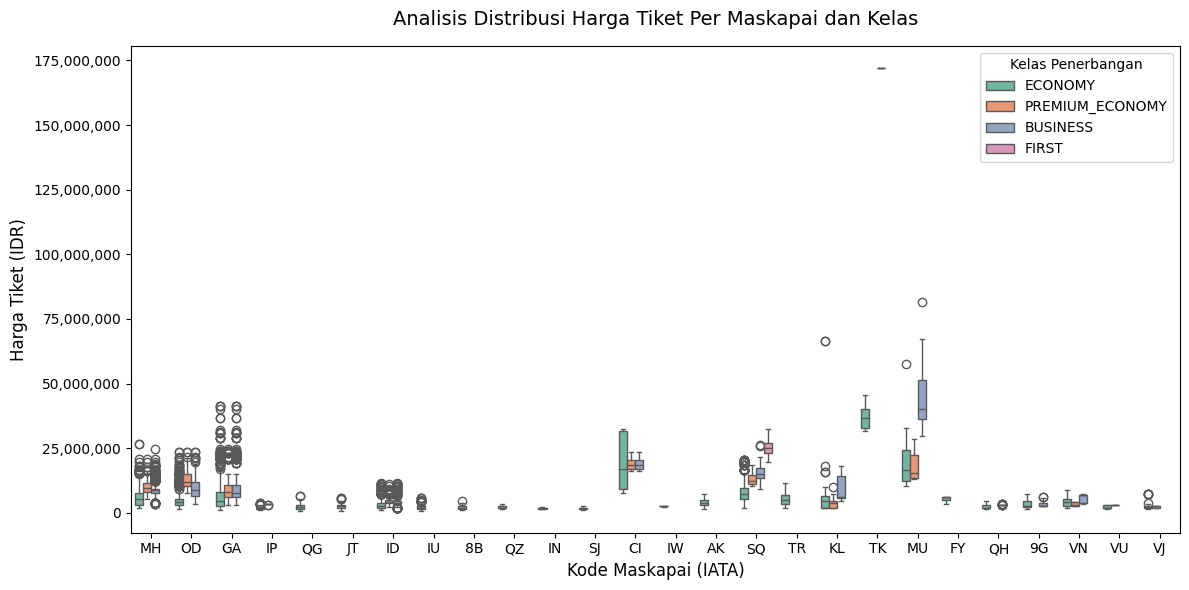

In [ ]:
plt.figure(figsize=(12, 6))

# gambar Boxplot menggunakan data maskapai_final, dan harga_idr
sns.boxplot(data=df_clean, x='maskapai_final', y='harga_idr', hue='kelas', palette='Set2')

formatter = ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)

# atribut grafik
plt.title('Analisis Distribusi Harga Tiket Per Maskapai dan Kelas', fontsize=14, pad=15)
plt.xlabel('Kode Maskapai (IATA)', fontsize=12)
plt.ylabel('Harga Tiket (IDR)', fontsize=12)
plt.legend(title='Kelas Penerbangan')
plt.tight_layout()
plt.show()

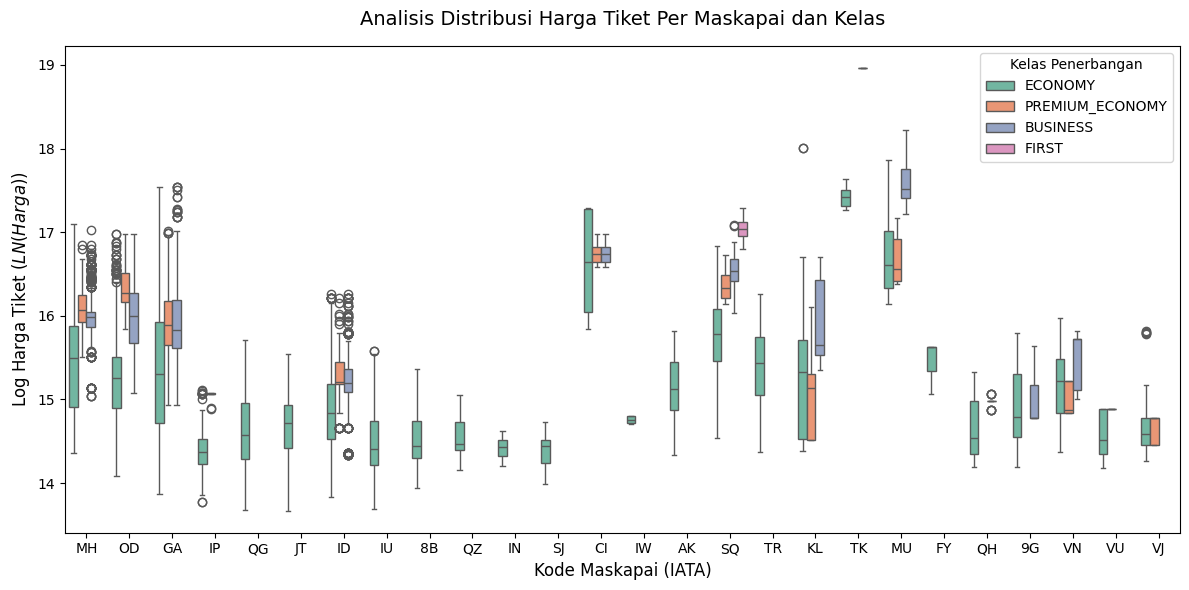

In [ ]:
plt.figure(figsize=(12, 6))

# membuat boxplot dengan harga_idr_log
sns.boxplot(data=df_clean, x='maskapai_final', y='harga_idr_log', hue='kelas', palette='Set2')

formatter = ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)

# atribut grafik
plt.title('Analisis Distribusi Harga Tiket Per Maskapai dan Kelas', fontsize=14, pad=15)
plt.xlabel('Kode Maskapai (IATA)', fontsize=12)
plt.ylabel('Log Harga Tiket ($LN(Harga)$)', fontsize=12)
plt.legend(title='Kelas Penerbangan')
plt.tight_layout()
plt.show()

Dari grafik terdapat satu tiket dari maskapai TK, yang memiliki nilai harga ekstrem.  
Berikut baris dengan nilai harga termahal pada dataset:

In [86]:
df_clean.loc[[df_clean['harga_idr'].idxmax()]]


,tanggal_scraping,bandara_asal,bandara_tujuan,tanggal_terbang,kelas,jam_berangkat,jam_tiba,tanggal_tiba,durasi_menit,transit,bagasi_kg,cabin_baggage_kg,meal,entertainment,usb,power,model_pesawat,seat_layout,seat_pitch_inch,seat_type,harga_idr,refundable,reschedulable,visa_required,wifi_status,maskapai_final,selisih_hari,hari_penerbangan,waktu_berangkat_kategori,waktu_tiba_kategori,jarak_km,is_transit,jumlah_fasilitas,harga_idr_log,harga_idr_scaled
11178,2026-05-20,KUL,CGK,2026-05-22,BUSINESS,05:30,17:35,2026-05-23,2225,1,40,8,True,True,True,True,Airbus A350,1-2-1,76.0,FULL_FLAT_POD,172103400,False,True,False,free,TK,2,4,EARLY_MORNING,AFTERNOON,1128.99784,1,5,18.963606,5.424972


Tiket tersebut berasal dari 'maskapai_final': TK 'kelas': BUSINESS dengan 'harga_idr': 172103400 yang merupakan outlier ekstrem pada dataset. Lonjakan ekstrem pada harga tertinggi ini diidentifikasi sebagai akibat dari skema transit multi-stop global (Kuala Lumpur - Istanbul - Jakarta) yang terekam pada saat proses scraping data.  

 Keberadaan pencilan ekstrem ini berhasil diatasi tanpa harus membuang data, yaitu dengan menerapkan Transformasi Logaritma pada variabel target ('harga_idr').

### Pengaruh jumlah fasilitas terhadap harga tiket:

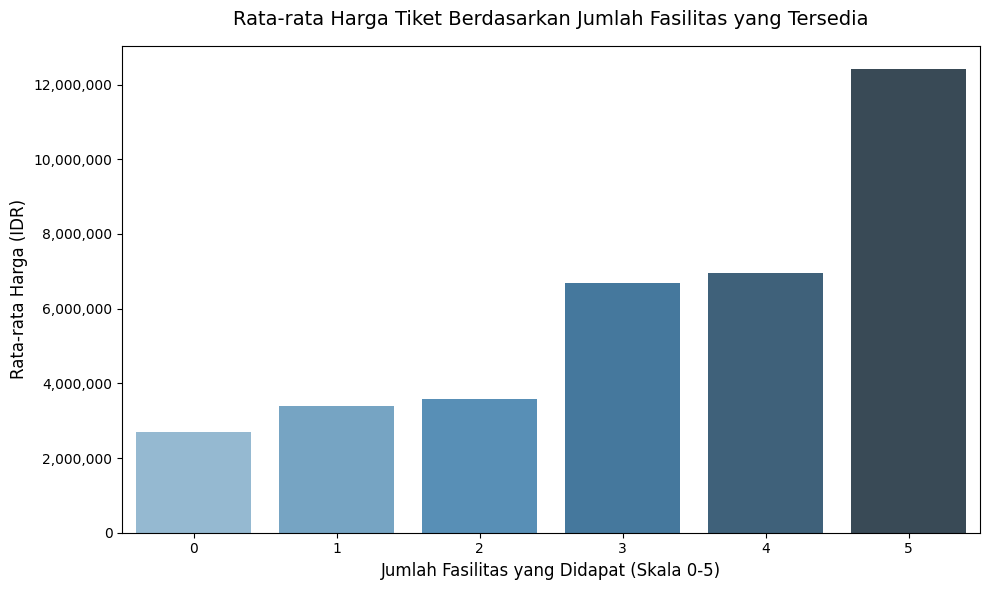

In [ ]:
plt.figure(figsize=(10, 6))
# menggunakan barplot untuk melihat rata-rata harga di setiap jumlah fasilitas
sns.barplot(data=df_clean, x='jumlah_fasilitas', y='harga_idr', palette='Blues_d', errorbar=None)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.title('Rata-rata Harga Tiket Berdasarkan Jumlah Fasilitas yang Tersedia', fontsize=14, pad=15)
plt.xlabel('Jumlah Fasilitas yang Didapat (Skala 0-5)', fontsize=12)
plt.ylabel('Rata-rata Harga (IDR)', fontsize=12)
plt.tight_layout()
plt.show()

Grafik menunjukkan tren kenaikan harga rata-rata yang sangat konsisten dan linear membentuk anak tangga ke kanan seiring bertambahnya bobot fasilitas (skala 0 hingga 5).  

Ekstraksi nilai biner fitur fasilitas ('meal', 'entertainment', 'usb', 'power', dan 'wifi_status') menjadi satu skor tunggal 'jumlah_fasilitas' berhasil menangkap korelasi positif yang kuat terhadap variabel target ('harga_idr'). Fitur ini akan sangat membantu algoritma regresi dalam memetakan nilai fasilitas secara linear tanpa memicu masalah multikolinieritas.

### Hubungan 'jarak_km' dengan 'harga_idr' dan 'is_transit'

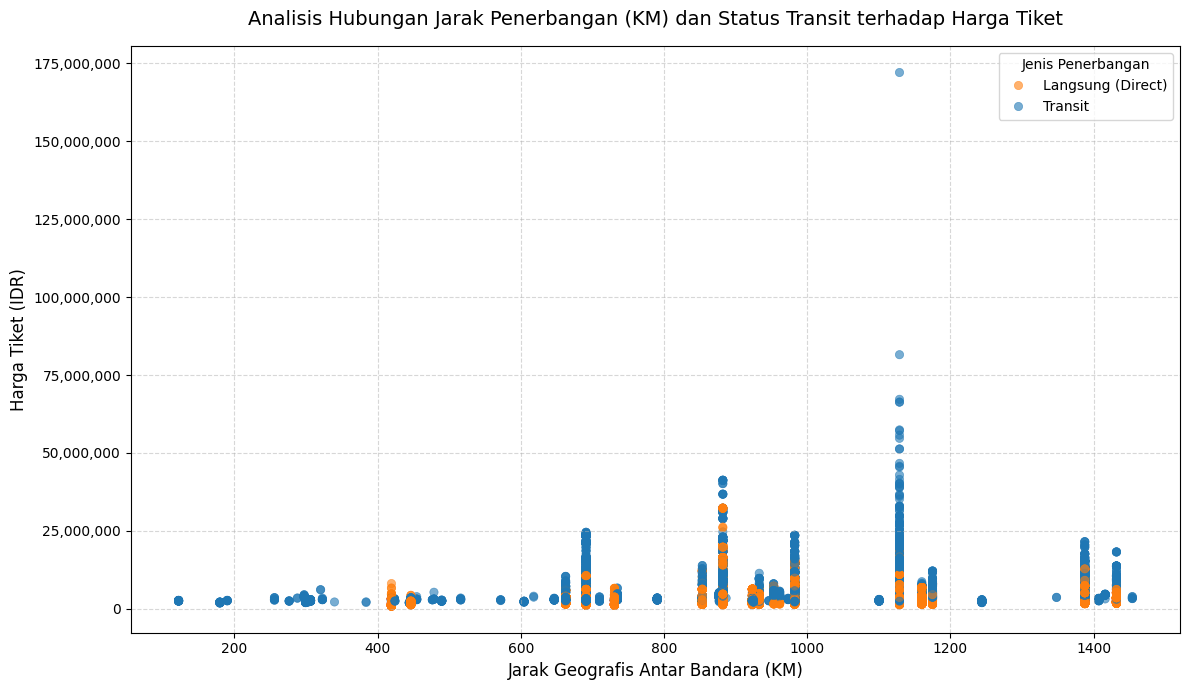

In [ ]:
plt.figure(figsize=(12, 7))

# membuat scatterplot untuk jarak_km dan harga_idr
sns.scatterplot(
    data=df_clean, 
    x='jarak_km', 
    y='harga_idr', 
    hue='is_transit', 
    palette={0: '#ff7f0e', 1: '#1f77b4'}, 
    alpha=0.6,
    edgecolor=None
)

formatter = ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x))
plt.gca().yaxis.set_major_formatter(formatter)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Jenis Penerbangan', labels=['Langsung (Direct)', 'Transit'])

# atribut grafik
plt.title('Analisis Hubungan Jarak Penerbangan (KM) dan Status Transit terhadap Harga Tiket', fontsize=14, pad=15)
plt.xlabel('Jarak Geografis Antar Bandara (KM)', fontsize=12)
plt.ylabel('Harga Tiket (IDR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

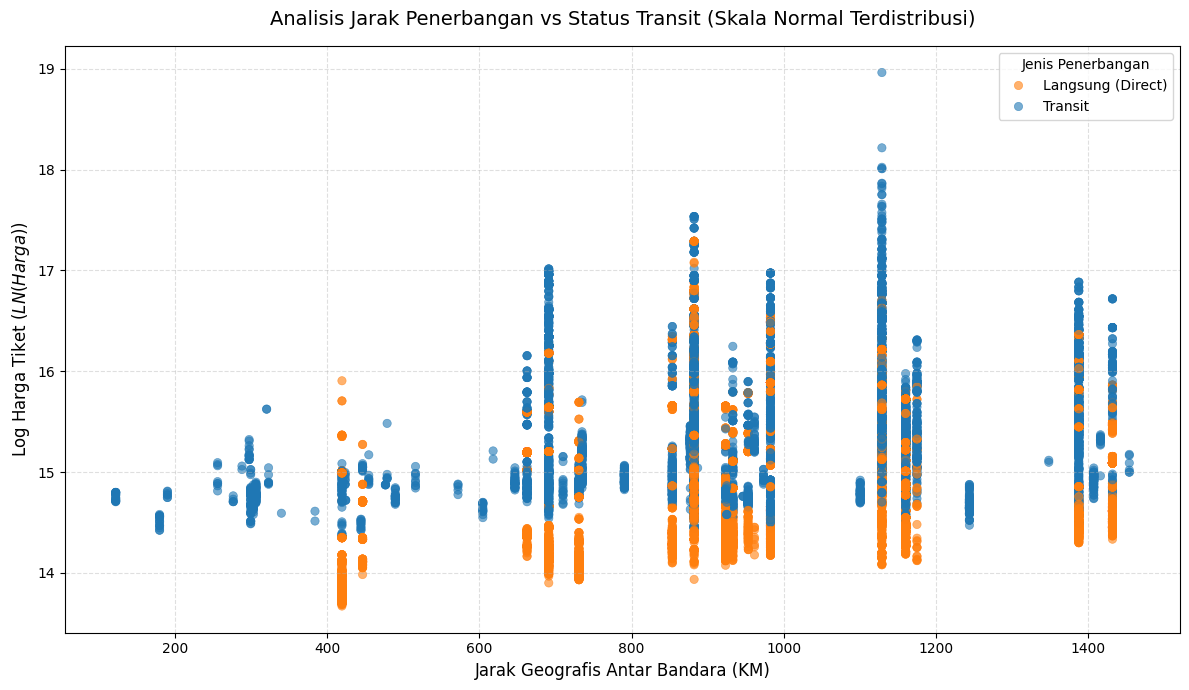

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# scatterplot dengan harga_idr_log
sns.scatterplot(
    data=df_clean, 
    x='jarak_km', 
    y='harga_idr_log', 
    hue='is_transit', 
    palette={0: '#ff7f0e', 1: '#1f77b4'}, 
    alpha=0.6,
    edgecolor=None
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=handles, title='Jenis Penerbangan', labels=['Langsung (Direct)', 'Transit'])

# atribut grafik menggunakan label skala logaritma
plt.title('Analisis Jarak Penerbangan vs Status Transit (Skala Normal Terdistribusi)', fontsize=14, pad=15)
plt.xlabel('Jarak Geografis Antar Bandara (KM)', fontsize=12)
plt.ylabel('Log Harga Tiket ($LN(Harga)$)', fontsize=12) # Menandakan ini skala log alami
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Jarak penerbangan memiliki hubungan positif terhadap harga tiket, tetapi bukan faktor yang dominan. Kemudian status transit cukup kuat berpengaruh terhadap distribusi harga (terlihat variasi harga terbesar muncul pada penerbangan transit).

### Pola perilaku pemesanan 'selisih_hari' terhadap waktu keberangkatan

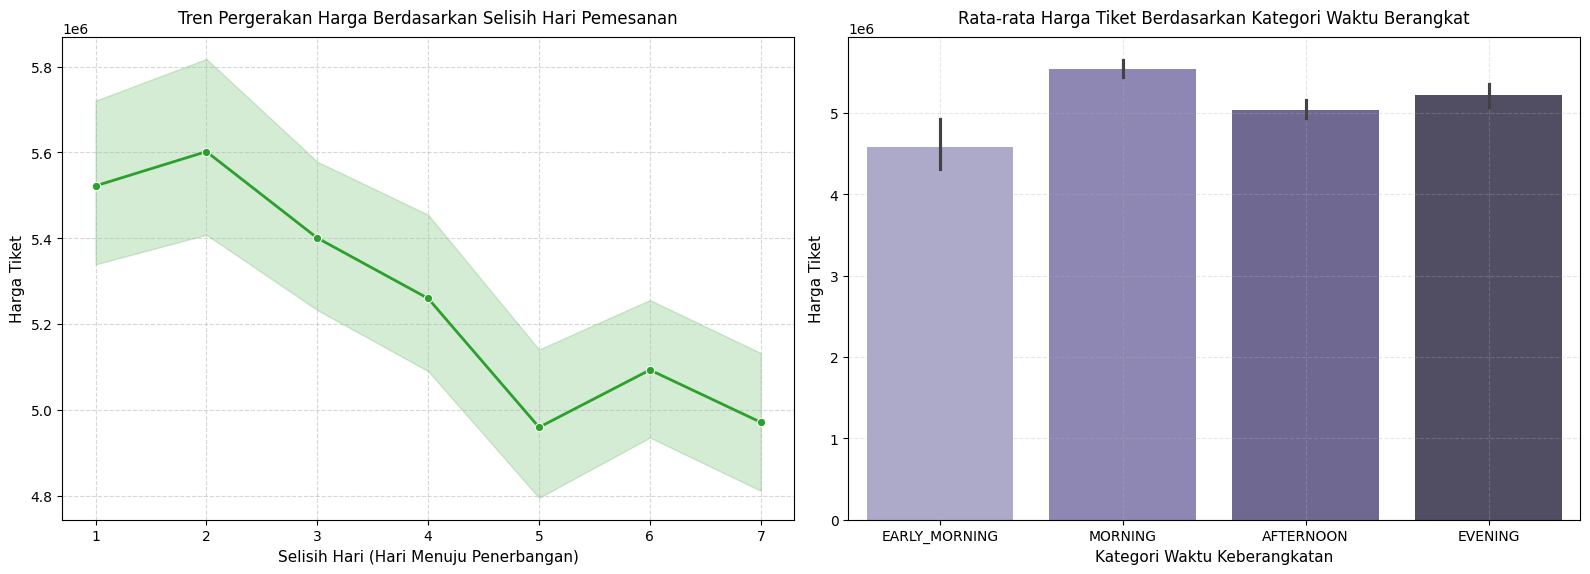

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# grafik 'selisih_hari' terhadap harga
sns.lineplot(
    data=df_clean, 
    x='selisih_hari', 
    y='harga_idr', 
    ax=axes[0], 
    marker='o', 
    color='#2ca02c', 
    linewidth=2
)
axes[0].set_title('Tren Pergerakan Harga Berdasarkan Selisih Hari Pemesanan', fontsize=12, pad=10)
axes[0].set_xlabel('Selisih Hari (Hari Menuju Penerbangan)', fontsize=11)
axes[0].set_ylabel('Harga Tiket', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)


# grafik perbandingan harga berdasarkan kategori waktu berangkat
urutan_waktu = ['EARLY_MORNING', 'MORNING', 'AFTERNOON', 'EVENING']

sns.barplot(
    data=df_clean, 
    x='waktu_berangkat_kategori', 
    y='harga_idr', 
    order=urutan_waktu,
    ax=axes[1], 
    palette='Purples_d'
)
axes[1].set_title('Rata-rata Harga Tiket Berdasarkan Kategori Waktu Berangkat', fontsize=12, pad=10)
axes[1].set_xlabel('Kategori Waktu Keberangkatan', fontsize=11)
axes[1].set_ylabel('Harga Tiket', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Korelasi fitur numerik pada dataset

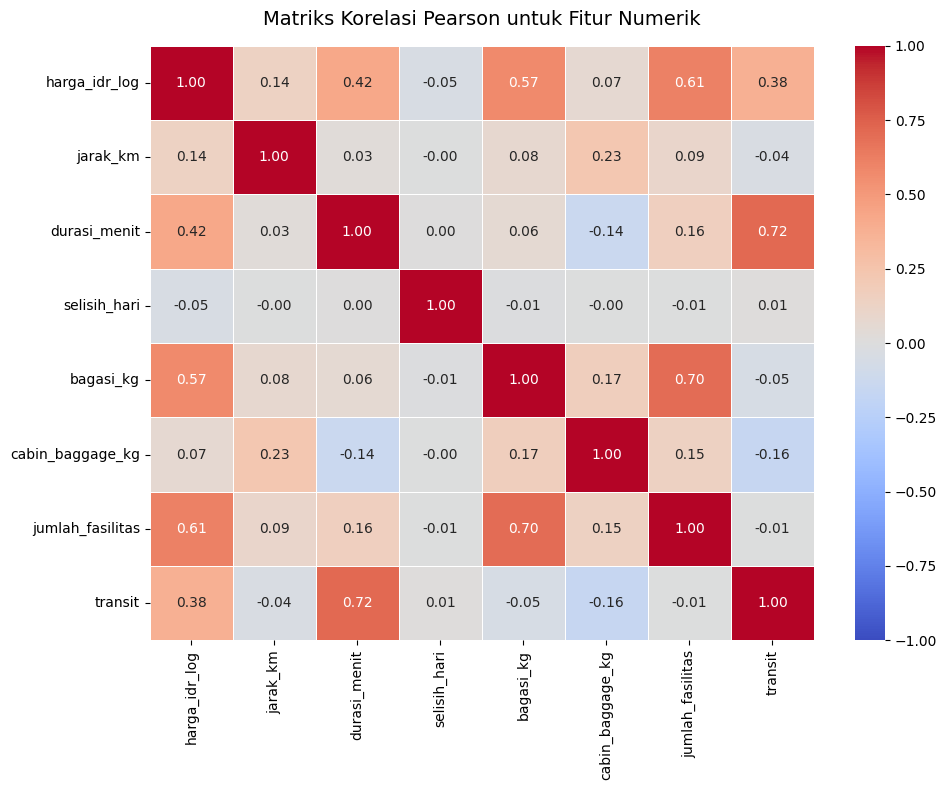

In [ ]:
plt.figure(figsize=(10, 8))

# pilih kolom-kolom numerik yang relevan untuk dianalisis harganya
kolom_numerik = [
    'harga_idr_log',     # Target utama (skala log)
    'jarak_km',          # Hasil rumus Haversine
    'durasi_menit',      # Durasi perjalanan
    'selisih_hari',      # Waktu pemesanan tiket
    'bagasi_kg',         # Kapasitas bagasi check-in
    'cabin_baggage_kg',  # Kapasitas bagasi kabin
    'jumlah_fasilitas',   # Fitur buatan (skala 0-5)
    'transit'
]

# hitung matriks korelasi menggunakan metode Pearson
matriks_korelasi = df_clean[kolom_numerik].corr(method='pearson')

# gambar Heatmap
sns.heatmap(
    matriks_korelasi, 
    annot=True,
    cmap='coolwarm',
    fmt='.2f', 
    linewidths=0.5,
    vmin=-1, vmax=1      # Membatasi rentang nilai indeks warna
)

plt.title('Matriks Korelasi Pearson untuk Fitur Numerik', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Dari matriks korelasi fitur numerik, dapat diketahui:
1. Fitur 'jumlah_fasilitas' (0.67), 'bagasi_kg' (0.57), punya korelasi kuat terhadap harga tiket pesawat ('harga_idr_log').  
Strategi bundling fasilitas, dan kuota bagasi menjadi instrumen utama maskapai dalam membedakan segmen kelas serta jenis pelayanan.  
2. Fitur 'transit' (0.38) dan 'durasi_menit' (0.42) memiliki pengaruh linear yang jauh lebih dominan terhadap harga dibandingkan faktor geografis murni 'jarak_km' (0.14)  
3. 

### Hubungan hari terhadap harga tiket:

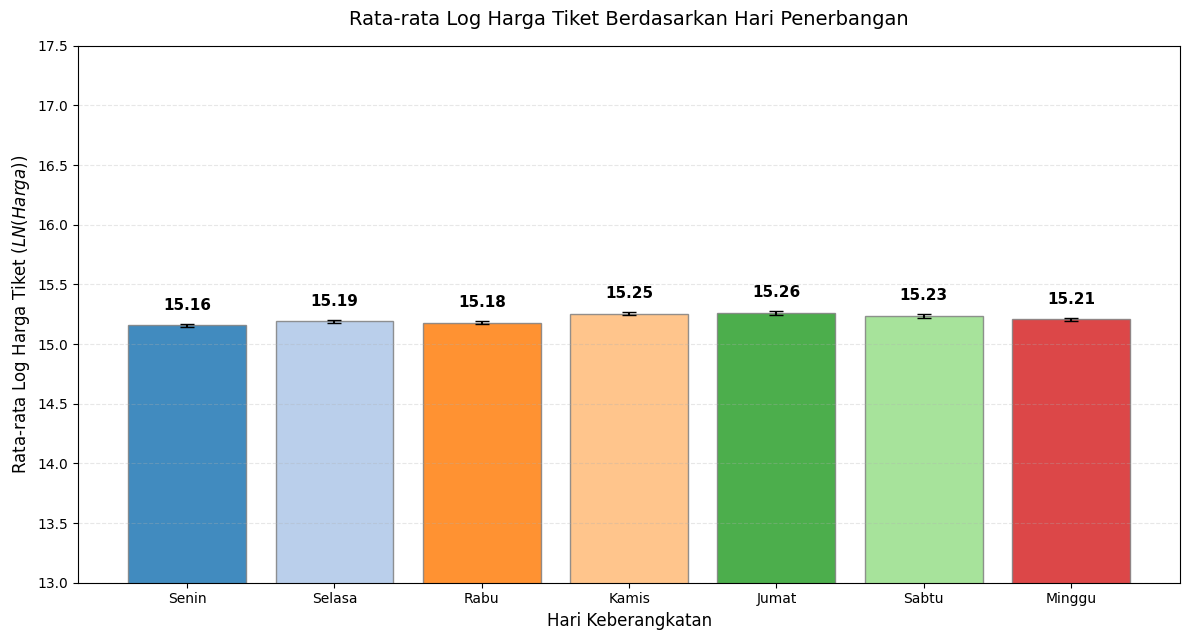

In [ ]:
# hitung rata-rata dan standar eror berdasarkan kolom 'hari_penerbangan' (0-6)
hari_indeks = range(7)
rata_rata_harga = [df_clean[df_clean['hari_penerbangan'] == i]['harga_idr_log'].mean() for i in hari_indeks]
standar_error = [df_clean[df_clean['hari_penerbangan'] == i]['harga_idr_log'].sem() for i in hari_indeks]

plt.figure(figsize=(12, 6.5))

# setup label teks hari dan warna
urutan_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728']

# gambar Bar Plot (simpan ke dalam variabel 'bars' agar bisa dibaca bar_label)
bars = plt.bar(
    urutan_hari, 
    rata_rata_harga, 
    yerr=standar_error, 
    color=colors, 
    alpha=0.85, 
    capsize=5, 
    edgecolor='grey'
)

plt.bar_label(bars, fmt='%.2f', padding=8, fontsize=11, weight='bold')
plt.ylim(13.0, 17.5) 

# atribut grafik
plt.title('Rata-rata Log Harga Tiket Berdasarkan Hari Penerbangan', fontsize=14, pad=15)
plt.xlabel('Hari Keberangkatan', fontsize=12)
plt.ylabel('Rata-rata Log Harga Tiket ($LN(Harga)$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Secara keseluruhan, rata-rata log harga tiket di setiap hari berada pada rentang yang sangat ketat, yaitu di kisaran 15.16 hingga 15.26. Jika dikembalikan ke nilai Rupiah asli melalui fungsi eksponensial, rata-rata harga bergerak stabil antara Rp3,800,000 hingga Rp4,200,000, dapat dikatakan faktor hari keberangkatan tidak memberikan guncangan harga ekstrem jika dibandingkan dengan faktor fasilitas komersial atau skema transit.  

Ini disebabkan karena keterbatasan cakupan dataset yang hanya mencakup tiket penerbangan pada 21 Mei hingga 28 Mei, di mana secara temporal sangat terbatas untuk menentukan pola pengaruh hari terhadap harga tiket pesawat.

## Encoding Fitur

Encoding adalah proses mengonversi data non-numerik (kategorikal atua teks) menjadi bentuk numerik, dengan tujuan agar data dapat dimengerti olhe komputer sehingga dapat menjadi model yang dapat digunakan.